In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Arun\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Arun\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
data = pd.read_csv("TMDB_movie_dataset_v11.csv")  

print(data.shape)
data.head()

(1446848, 24)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [3]:
data = data[['title','overview','genres','keywords','vote_average','vote_count']]

In [4]:
print(data.shape)

(1446848, 6)


In [5]:
data = data.drop_duplicates(
    subset='title'
)

data = data.reset_index(
    drop=True
)

print(data.shape)

(1227491, 6)


In [6]:
data['genres'] = data['genres'].fillna('')
data['keywords'] = data['keywords'].fillna('')
data['overview'] = data['overview'].fillna('')

In [7]:
data['content'] = (
    data['genres'] + ' ' +
    data['genres'] + ' ' +
    data['genres'] + ' ' +
    data['keywords'] + ' ' +
    data['keywords'] + ' ' +
    data['overview']
)

In [8]:
combined_text = " ".join(data['content'].astype(str))

In [9]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=300
).generate(combined_text)

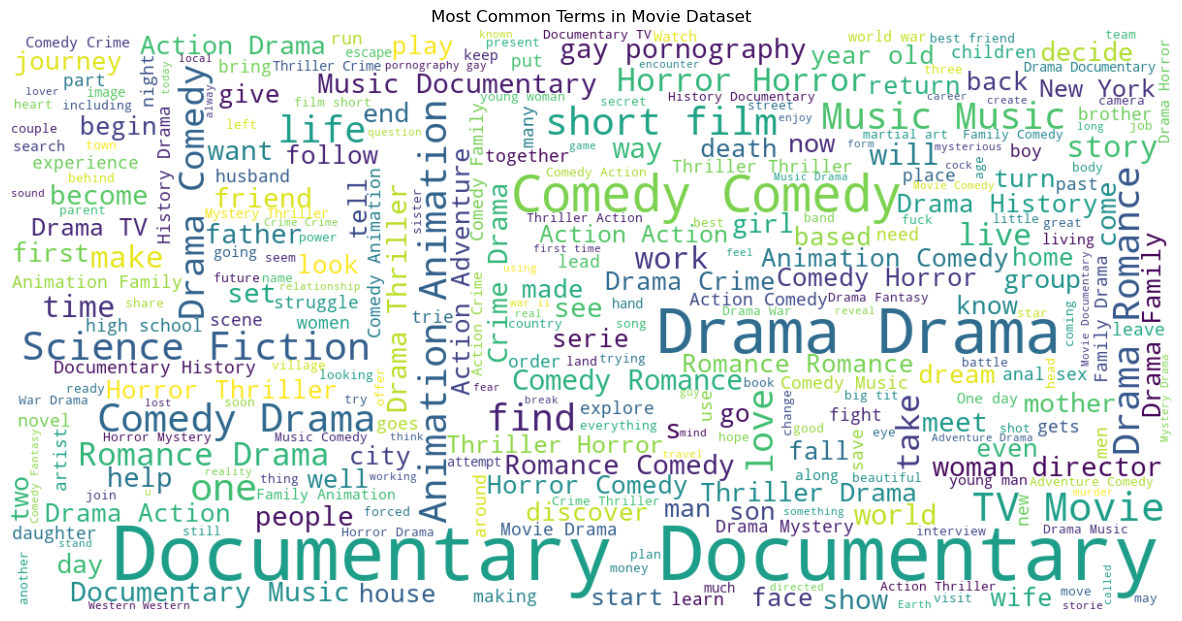

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Terms in Movie Dataset')
plt.show()

In [11]:
from collections import Counter

words = combined_text.split()

word_freq = Counter(words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word', 'Frequency']
)

top_words

,Word,Frequency
0,the,2150983
1,and,1327457
2,of,1302989
3,a,1275728
4,to,1063384
5,in,760698
6,is,516570
7,Documentary,483466
8,Drama,411992
9,his,408103


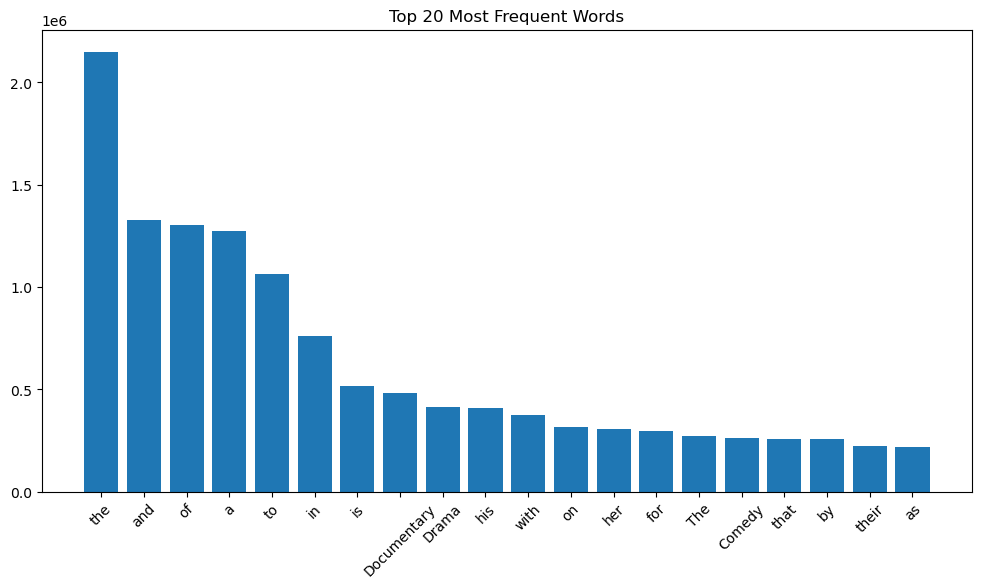

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    top_words['Word'],
    top_words['Frequency']
)

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [14]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text))
    text = text.lower()

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [15]:
data['cleaned_content'] = data['content'].apply(preprocess_text)

In [16]:
print(data.columns.tolist())

['title', 'overview', 'genres', 'keywords', 'vote_average', 'vote_count', 'content', 'cleaned_content']


In [17]:
combined_text = " ".join(data['cleaned_content'].astype(str))

In [21]:
custom_stopwords = {
    'film',
    'movie',
    'one',
    'new',
    'young',
    'world',
    'life'
}

In [18]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=300
).generate(combined_text)

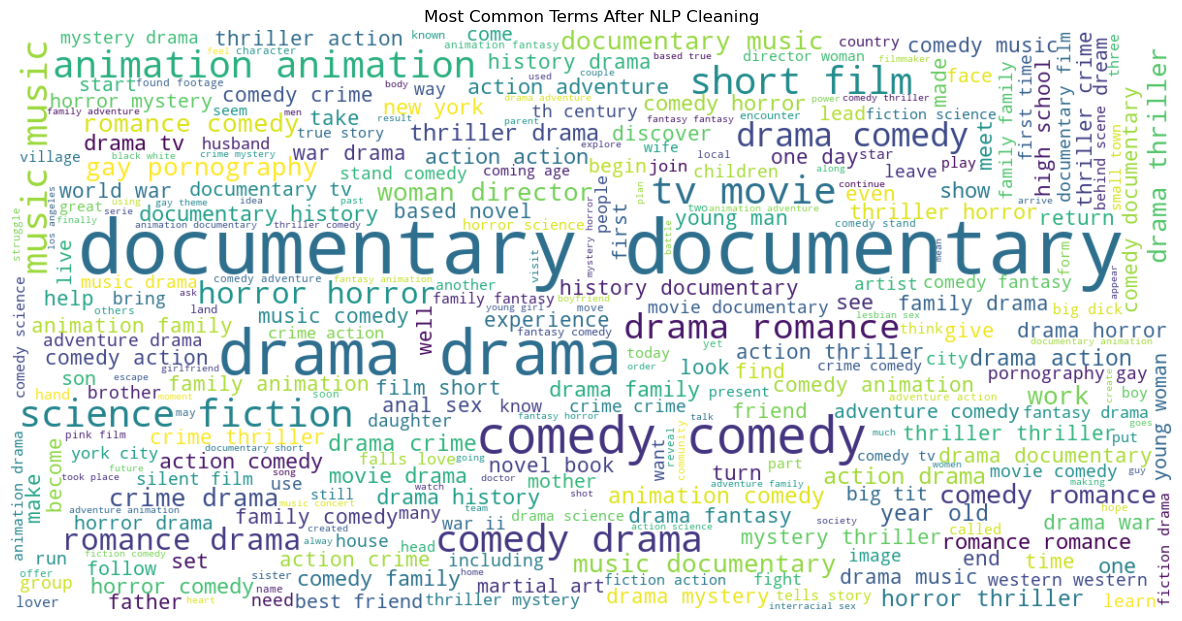

In [19]:
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Terms After NLP Cleaning")
plt.show()

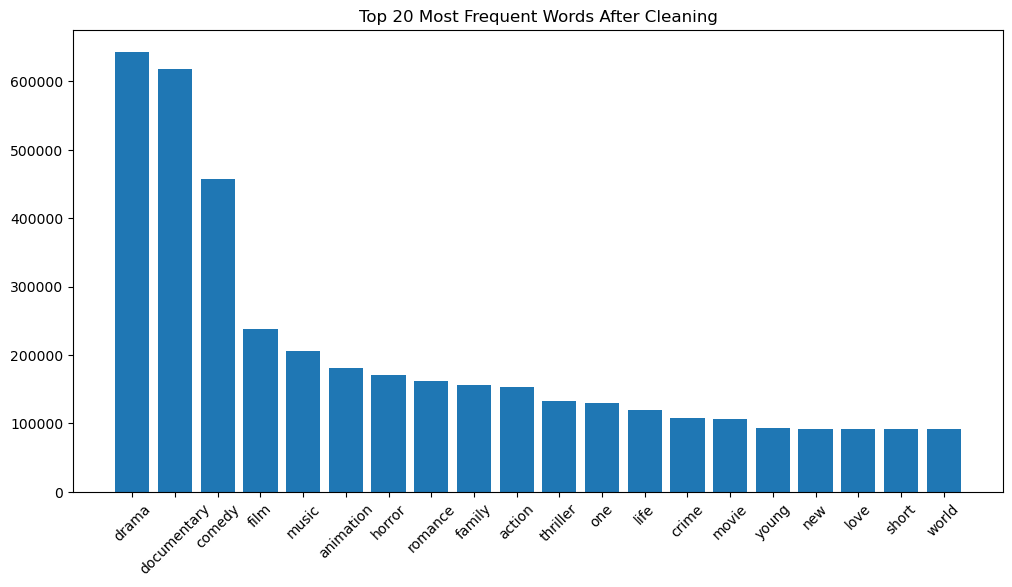

In [20]:
words = combined_text.split()

word_freq = Counter(words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(12,6))
plt.bar(top_words['Word'], top_words['Frequency'])

plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.show()

In [24]:
tfidf = TfidfVectorizer(
    max_features=15000,
    stop_words='english',
    ngram_range=(1,2),
    min_df=3
)

tfidf_matrix = tfidf.fit_transform(
    data['cleaned_content']
)

print(tfidf_matrix.shape)

(1227491, 15000)


In [27]:
nn_model = NearestNeighbors(
    n_neighbors=11,
    metric='cosine',
    algorithm='brute'
)

nn_model.fit(tfidf_matrix)

print("Model trained!")

Model trained!


In [28]:
title_to_index = pd.Series(
    data.index,
    index=data['title']
).drop_duplicates()

In [29]:
print(len(title_to_index))

1227491


In [30]:
def recommend(movie_name, n=10):

    if movie_name not in title_to_index:
        return "Movie not found"

    idx = title_to_index[movie_name]

    distances, indices = nn_model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=n+1
    )

    recommendations = []

    for i, d in zip(
        indices.flatten()[1:],
        distances.flatten()[1:]
    ):

        recommendations.append(
            {
                "title": data.iloc[i]['title'],
                "similarity": round(1-d, 4)
            }
        )

    return pd.DataFrame(recommendations)

In [31]:
recommend("Inception")

,title,similarity
0,末日战士,0.4537
1,Heavy Armor 4: Monster Attack,0.4537
2,A Odisséia de Zia,0.4537
3,佣兵特战队,0.4537
4,星门深渊,0.4431
5,The Invasion of Red-Coke City,0.4431
6,重返侏罗纪,0.4420
7,Foda City: Guerra Infinita,0.4420
8,Avatar 3,0.4266
9,Battle of the Damned,0.4238


In [32]:
recommend("Interstellar")

,title,similarity
0,Silent Running,0.4605
1,Budhayaan,0.4402
2,Assignment: Outer Space,0.4312
3,Conquest of Space,0.4299
4,Journey to the Far Side of the Sun,0.4270
5,Mutiny in Outer Space,0.4231
6,Epilogue (WT),0.4198
7,Journey to Space,0.4162
8,Stowaway,0.4052
9,The 21st Century Race For Space,0.4000


In [33]:
recommend("The Dark Knight")

,title,similarity
0,Batman Begins,0.4486
1,Batman,0.4350
2,Batman: Mask of the Phantasm,0.4078
3,The Dark Knight Rises,0.4068
4,Batman Forever,0.3862
5,Spectre: Genesis,0.3762
6,Tiro Certo,0.3757
7,Star Reporter,0.3756
8,Break a Bullet,0.3718
9,Three And A Bullet,0.3631


In [35]:
def recommend(movie_name, n=10):

    if movie_name not in title_to_index:
        return "Movie not found"

    idx = title_to_index[movie_name]

    distances, indices = nn_model.kneighbors(
        tfidf_matrix[idx],
        n_neighbors=n+1
    )

    recommendations = []

    for i, d in zip(
        indices.flatten()[1:],
        distances.flatten()[1:]
    ):

        similarity = 1 - d

        rating = data.iloc[i]['vote_average']

        final_score = (
            0.7 * similarity +
            0.3 * (rating / 10)
        )

        recommendations.append({
            "title": data.iloc[i]['title'],
            "similarity": round(similarity, 4),
            "rating": rating,
            "final_score": round(final_score, 4)
        })

    recommendations = pd.DataFrame(recommendations)

    recommendations = recommendations.sort_values(
        "final_score",
        ascending=False
    )

    return recommendations

In [36]:
recommend("The Dark Knight")

,title,similarity,rating,final_score
0,Batman Begins,0.4486,7.701,0.5450
1,Batman,0.4350,7.200,0.5205
3,The Dark Knight Rises,0.4068,7.777,0.5181
2,Batman: Mask of the Phantasm,0.4078,7.486,0.5100
4,Batman Forever,0.3862,5.409,0.4326
7,Star Reporter,0.3756,5.200,0.4189
5,Spectre: Genesis,0.3762,0.000,0.2633
6,Tiro Certo,0.3757,0.000,0.2630
8,Break a Bullet,0.3718,0.000,0.2603
9,Three And A Bullet,0.3631,0.000,0.2542


In [37]:
recommend("Interstellar")

,title,similarity,rating,final_score
9,The 21st Century Race For Space,0.4000,8.000,0.5200
0,Silent Running,0.4605,6.390,0.5140
4,Journey to the Far Side of the Sun,0.4270,6.200,0.4849
7,Journey to Space,0.4162,6.200,0.4773
3,Conquest of Space,0.4299,5.613,0.4693
8,Stowaway,0.4052,5.984,0.4631
5,Mutiny in Outer Space,0.4231,5.200,0.4522
2,Assignment: Outer Space,0.4312,3.810,0.4162
1,Budhayaan,0.4402,0.000,0.3081
6,Epilogue (WT),0.4198,0.000,0.2938


In [38]:
recommend("Inception")

,title,similarity,rating,final_score
7,Foda City: Guerra Infinita,0.4420,8.00,0.5494
9,Battle of the Damned,0.4238,4.62,0.4353
0,末日战士,0.4537,0.00,0.3176
1,Heavy Armor 4: Monster Attack,0.4537,0.00,0.3176
2,A Odisséia de Zia,0.4537,0.00,0.3176
3,佣兵特战队,0.4537,0.00,0.3176
4,星门深渊,0.4431,0.00,0.3102
5,The Invasion of Red-Coke City,0.4431,0.00,0.3102
6,重返侏罗纪,0.4420,0.00,0.3094
8,Avatar 3,0.4266,0.00,0.2986


In [39]:
import pickle

pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(nn_model, open("nn_model.pkl", "wb"))
pickle.dump(data, open("movies_data.pkl", "wb"))

In [42]:
from scipy import sparse

sparse.save_npz(
    "tfidf_matrix.npz",
    tfidf_matrix
)

In [43]:
tfidf_matrix.shape

(1227491, 15000)

In [44]:
sparse.save_npz("tfidf_matrix.npz", tfidf_matrix)